<a href="https://colab.research.google.com/github/haftamugebremaryam16/Machine-Learning/blob/main/Polynomial_Regression_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# first dowload Ice_cream selling data.csv from kaggle then upload into google colab'
df=pd.read_csv('/content/Ice_cream selling data.csv')

In [ ]:
df.isnull().sum()

,0
Temperature (°C),0
Ice Cream Sales (units),0


In [ ]:
corr=df.corr()
corr

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [ ]:
def z_score(x):
  mu=np.mean(x,axis=0)
  std=np.std(x,axis=0)
  return (x-mu)/std,mu,std

as you saw in the above plot the picture look like $$ x^2$$ function

> Add blockquote



$$f(x)=w_1x+w_2x^2+b$$

1.   List item
2.   List item



$$
J(w,b)=\frac{1}{2m} \sum_{i=1}^{m}(f(x^{(i)})-y^{(i)})^2
$$

In [ ]:
def cost_compute(x, y, w1, w2, b):
    m = x.shape[0]

    f_x = w1*x + w2*(x**2) + b

    err = f_x - y

    total_cost = np.sum(err**2)

    return total_cost / (2*m)

$$
\frac {\partial J(w,b)}{\partial {w_1}}=\frac{1}{m} \sum_{i=1}^{m} (f(x^{(i)})-y^{(i)}).(x^{(i)})
$$
$$
\frac {\partial J(w,b)}{\partial {w_2}}=\frac {1}{m} \sum_{i=1}^{m} (f(x^{(i)})-y^{(i)}).(x^{(i)})^2
$$
$$
\frac {\partial J(w,b)}{\partial {b}}=\frac {1}{m} \sum_{i=1}^{m} (f(x^{(i)})-y^{(i)})
$$



In [ ]:
def compute_gradient(x, y, w1, w2, b):
    m = x.shape[0]

    f_x = w1*x + w2*(x**2) + b

    err = f_x - y

    dw1 = np.sum(err * x) / m
    dw2 = np.sum(err * (x**2)) / m
    db  = np.sum(err) / m

    return dw1, dw2, db

until converge
{
$$
w1=w1-\alpha *\frac {\partial J(w,b)}{\partial w_1}
$$
$$
w2=w2-\alpha *\frac {\partial J(w,b)}{\partial w_2}
$$
$$
b=b-\alpha *\frac {\partial J(w,b)}{\partial b}
$$
}


In [ ]:
def gradient_descent(x, y, w1_in, w2_in, b_in, alpha, num_iter):

    w1 = w1_in
    w2 = w2_in
    b = b_in

    cost_history = []

    for i in range(num_iter):

        dw1, dw2, db = compute_gradient(x, y, w1, w2, b)

        w1 = w1 - alpha * dw1
        w2 = w2 - alpha * dw2
        b  = b  - alpha * db

        cost_history.append(cost_compute(x, y, w1, w2, b))

    return w1, w2, b, cost_history

In [ ]:
X_train=np.array(df['Temperature (°C)'])
y_train=np.array(df['Ice Cream Sales (units)'])


In [ ]:
X_norm,mu,std=z_score(X_train)

In [ ]:
alpha=0.01
num_iter=1000
w1_in=w2_in=0
b_in=0
f_w1, f_w2, f_b, cost = gradient_descent(X_norm,y_train,w1_in, w2_in, b_in, alpha, num_iter)

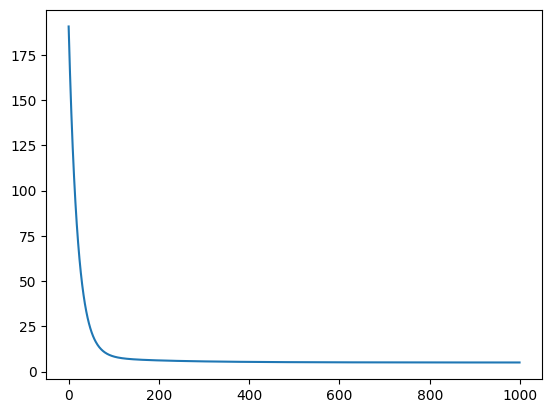

In [ ]:
plt.plot(cost)
plt.show()

In [ ]:
y_pred=f_w1*X_norm+f_w2*(X_norm**2)+f_b
y_mean=np.mean(y_train)
ss_tot=np.sum((y_train-y_mean)**2)
ss_res=np.sum((y_train-y_pred)**2)
r2=1-(ss_res/ss_tot)
print(r2)

0.9320082182100891


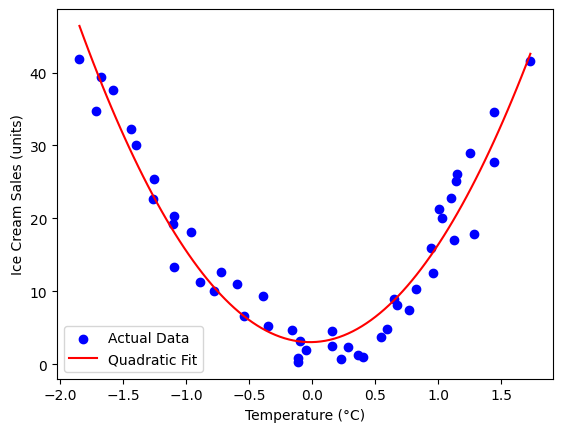

In [ ]:

X_range = np.linspace(X_norm.min(), X_norm.max(), 100)
y_plot = f_w1*X_range+f_w2*(X_range**2)+f_b
plt.scatter(X_norm, y_train, color='blue', label='Actual Data')
plt.plot(X_range, y_plot, color='red', label='Quadratic Fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.legend()
plt.show()